In [ ]:
!pip install nba_api

In [ ]:
import pandas as pd
import time
from nba_api.stats.endpoints import leaguedashplayerbiostats, leaguedashplayerclutch

# Define the 12-season scope: 2012-13 to 2023-24
seasons = [f"{year}-{str(year+1)[-2:]}" for year in range(2012, 2024)]
bio_data = []
clutch_data = []

print("Environment ready. Seasons to fetch:", seasons)

Environment ready. Seasons to fetch: ['2012-13', '2013-14', '2014-15', '2015-16', '2016-17', '2017-18', '2018-19', '2019-20', '2020-21', '2021-22', '2022-23', '2023-24']


In [ ]:
print("Starting Data Extraction...")

for season in seasons:
    # 1. Fetch Physical Traits (Bio Stats)
    for attempt in range(3):
        try:
            print(f"Fetching Bio data for {season}...")
            bio = leaguedashplayerbiostats.LeagueDashPlayerBioStats(season=season, timeout=30)
            df_bio = bio.get_data_frames()[0]
            df_bio['SEASON'] = season
            bio_data.append(df_bio)
            time.sleep(2)
            break
        except Exception as e:
            print(f"Bio Timeout. Retrying... (Attempt {attempt + 1}/3)")
            time.sleep(5)

    # 2. Fetch True Clutch Stats (Last 5 mins, within 5 points)
    for attempt in range(3):
        try:
            print(f"Fetching Clutch data for {season}...")
            # Removed the _nullable suffixes that were causing the crash!
            stats = leaguedashplayerclutch.LeagueDashPlayerClutch(
                season=season,
                clutch_time='Last 5 Minutes',
                point_diff=5,
                ahead_behind='Ahead or Behind',
                timeout=30
            )
            df_stats = stats.get_data_frames()[0]
            df_stats['SEASON'] = season
            clutch_data.append(df_stats)
            time.sleep(2)
            break
        except Exception as e:
            print(f"Clutch Error. Retrying... (Attempt {attempt + 1}/3) Error message: {e}")
            time.sleep(5)

print("\nData Extraction Complete.")

Starting Data Extraction...
Fetching Bio data for 2012-13...
Fetching Clutch data for 2012-13...
Fetching Bio data for 2013-14...
Fetching Clutch data for 2013-14...
Fetching Bio data for 2014-15...
Fetching Clutch data for 2014-15...
Fetching Bio data for 2015-16...
Fetching Clutch data for 2015-16...
Fetching Bio data for 2016-17...
Fetching Clutch data for 2016-17...
Fetching Bio data for 2017-18...
Fetching Clutch data for 2017-18...
Fetching Bio data for 2018-19...
Fetching Clutch data for 2018-19...
Fetching Bio data for 2019-20...
Fetching Clutch data for 2019-20...
Fetching Bio data for 2020-21...
Fetching Clutch data for 2020-21...
Fetching Bio data for 2021-22...
Fetching Clutch data for 2021-22...
Fetching Bio data for 2022-23...
Fetching Clutch data for 2022-23...
Fetching Bio data for 2023-24...
Fetching Clutch data for 2023-24...

Data Extraction Complete.


In [ ]:
print("Merging and Cleaning Data...")

# Combine the lists into master dataframes
df_all_bio = pd.concat(bio_data, ignore_index=True)
df_all_clutch = pd.concat(clutch_data, ignore_index=True)

# Merge on Player ID, Name, and Season
merged_df = pd.merge(
    df_all_bio[['PLAYER_ID', 'PLAYER_NAME', 'SEASON', 'PLAYER_HEIGHT_INCHES', 'PLAYER_WEIGHT']],
    df_all_clutch,
    on=['PLAYER_ID', 'PLAYER_NAME', 'SEASON'],
    how='inner'
)

# Handle legacy weight strings: convert to numeric, coerce errors to NaN
merged_df['PLAYER_WEIGHT'] = pd.to_numeric(merged_df['PLAYER_WEIGHT'], errors='coerce')

# Drop rows where essential physical traits are missing
merged_df = merged_df.dropna(subset=['PLAYER_WEIGHT', 'PLAYER_HEIGHT_INCHES']).copy()

print(f"Merged and cleaned data. Current rows: {len(merged_df)}")

Merging and Cleaning Data...
Merged and cleaned data. Current rows: 5399


In [ ]:
print("Engineering Features and Applying Thresholds (Milestone 2 Workflow)...")

# 1. BASIC CALCULATIONS (On the raw merged data)
# Calculate BMI: (Weight in lbs / Height in inches squared) * 703
merged_df['BMI'] = (merged_df['PLAYER_WEIGHT'] / (merged_df['PLAYER_HEIGHT_INCHES'] ** 2)) * 703

# Calculate Points Per Minute (Clutch Efficiency)
merged_df['PTS_PER_MIN'] = merged_df.apply(
    lambda row: row['PTS'] / row['MIN'] if row['MIN'] > 0 else 0,
    axis=1
)

# 2. DATETIME CONVERSION (Requirement for Lesson 5: Trends)
# Extract starting year (e.g., '2012' from '2012-13')
merged_df['SEASON_START_YEAR'] = merged_df['SEASON'].str.split('-').str[0].astype(int)
# Convert to a proper Pandas DateTime object (assuming season starts in October)
merged_df['SEASON_DT'] = pd.to_datetime(merged_df['SEASON_START_YEAR'].astype(str) + '-10-01')

# 3. STATISTICAL NOISE FILTERING (Dropping bottom 25% of minutes)
# Calculate the 25th percentile (Q1) of clutch minutes
q1_min_threshold = merged_df['MIN'].quantile(0.25)
# Filter out the bottom 25% (creates final_df)
final_df = merged_df[merged_df['MIN'] >= q1_min_threshold].copy()

# 4. QUANTILE-BASED ARCHETYPES
# Assign Quantile-Based Archetypes (Bottom 33%, Middle 33%, Top 33%) based on BMI
final_df['PHYSICAL_ARCHETYPE'] = pd.qcut(
    final_df['BMI'],
    q=3,
    labels=['Lighter/Agile (Bottom 33%)', 'Balanced (Middle 33%)', 'Heavier/Power (Top 33%)']
)

# Logging for Milestone 2 Compliance
print(f"✅ Success: Dataset filtered using Q1 threshold of {q1_min_threshold:.2f} mins.")
print(f"✅ Success: DateTime conversion complete (Column: SEASON_DT).")
print(f"Final dataset rows: {len(final_df)}")

Engineering Features and Applying Thresholds (Milestone 2 Workflow)...
✅ Success: Dataset filtered using Q1 threshold of 9.09 mins.
✅ Success: DateTime conversion complete (Column: SEASON_DT).
Final dataset rows: 4049


In [ ]:
print("Engineering Features and Applying Thresholds...")

# 1. Calculate BMI: (Weight in lbs / Height in inches squared) * 703
merged_df['BMI'] = (merged_df['PLAYER_WEIGHT'] / (merged_df['PLAYER_HEIGHT_INCHES'] ** 2)) * 703

# 2. Calculate Points Per Minute (Clutch Efficiency)
# Using a lambda function to avoid division by zero
merged_df['PTS_PER_MIN'] = merged_df.apply(
    lambda row: row['PTS'] / row['MIN'] if row['MIN'] > 0 else 0,
    axis=1
)

# 3. Assign Quantile-Based Archetypes (Bottom 33%, Middle 33%, Top 33%) based on BMI
merged_df['PHYSICAL_ARCHETYPE'] = pd.qcut(
    merged_df['BMI'],
    q=3,
    labels=['Lighter/Agile (Bottom 33%)', 'Balanced (Middle 33%)', 'Heavier/Power (Top 33%)']
)

# 4. Filter out noise (Minimum minutes threshold: >= 10 clutch minutes per season)
final_df = merged_df[merged_df['MIN'] >= 10].copy()

print(f"Feature engineering complete. Filtered out low-minute noise.")

Engineering Features and Applying Thresholds...
Feature engineering complete. Filtered out low-minute noise.


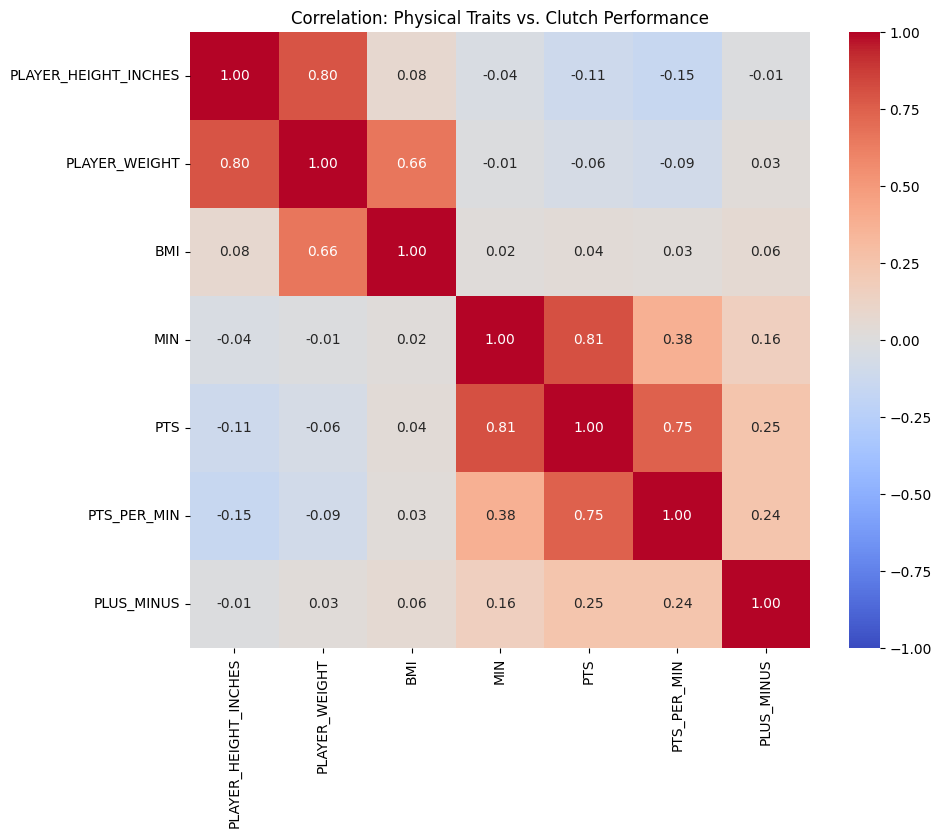

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Select ONLY the columns relevant to your proposal
cols_to_plot = ['PLAYER_HEIGHT_INCHES', 'PLAYER_WEIGHT', 'BMI', 'MIN', 'PTS', 'PTS_PER_MIN', 'PLUS_MINUS']
subset_corr = final_df[cols_to_plot].corr()

# 2. Make the canvas larger (width, height)
plt.figure(figsize=(10, 8))

# 3. Plot the heatmap
# Using 'coolwarm' cmap makes positive correlations red and negative ones blue
sns.heatmap(subset_corr,
            annot=True,        # Show the numbers
            cmap='coolwarm',   # Better color scale
            fmt=".2f",         # Round to 2 decimal places so numbers fit
            vmin=-1, vmax=1)   # Anchor the color scale from -1 to 1

plt.title("Correlation: Physical Traits vs. Clutch Performance")
plt.show()